# Storage Destructuring

Most value storages split containers (`list`, `tuple`, `dict`, dataclasses, attrs classes) into **content-addressed entries**: each part is stored under the SHA-256 digest of its content, and identical sub-structure is stored only once. This notebook walks through the three destructuring figures from the documentation and rebuilds every depicted layout in a `ValueMemory` storage, so you can poke at the exact entries. The digest labels in the figures are real — the code below reproduces them.

## Deduplication

`xs` and `ys` below share the sub-list `[2, 3]`. On `save()` each value is destructured: the shared sub-list digests to the same key both times, so storage keeps a single copy and both parents hold a digest reference in its place. `load()` follows the references and mends the original nesting.

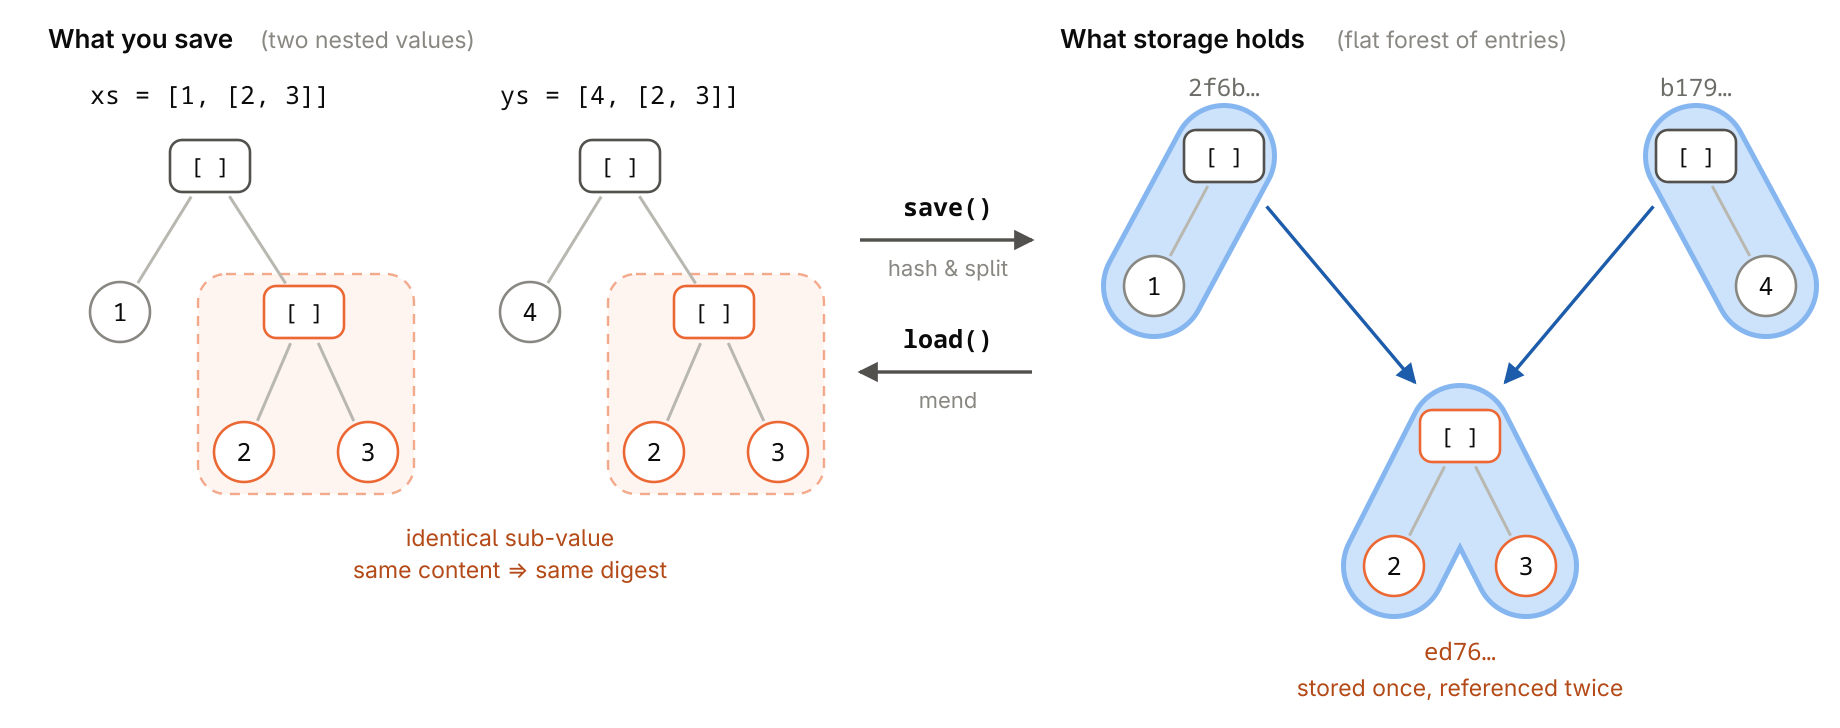

The same layout, built by hand. With the default `remaining_depth = 1` the scalars `1` and `4` stay inline in their parent entries, so the store ends up with exactly three entries:

In [1]:
from fleche.storage import ValueMemory

xs = [1, [2, 3]]
ys = [4, [2, 3]]

values = ValueMemory({})
key_xs = values.save(xs)
key_ys = values.save(ys)
len(values.storage)

3

`values.storage` is a plain dict of raw entries. Full digests are 64 characters, so this helper shrinks every digest to its shortest unambiguous prefix — `shrink` is also what produced the labels in the figures:

In [2]:
import re


def dump(storage):
    """Print every raw entry, with digests shrunk to their short form."""
    for key, raw in storage.storage.items():
        entry = re.sub(
            r"[0-9a-f]{64}",
            lambda m: storage.shrink(m.group(0)) + "\u2026",
            repr(raw),
        )
        print(f"{storage.shrink(key)}\u2026  {entry}")


dump(values)

ed76…  [2, 3]
2f6b…  DigestedIterable(items=[1, 'ed76…'])
b179…  DigestedIterable(items=[4, 'ed76…'])


The sub-list `[2, 3]` was stored first (children are interned before their parents) and appears exactly once; both roots hold its digest. `count_reuses()` tallies how often each entry is referenced by other entries:

In [3]:
{values.shrink(key) + "\u2026": n for key, n in values.count_reuses().items()}

{'ed76…': 2, '2f6b…': 0, 'b179…': 0}

Loading mends the trees back together — the `DigestedIterable` wrappers are invisible to the caller:

In [4]:
values.load(key_xs) == xs and values.load(key_ys) == ys

True

## `remaining_depth`

How finely a value is split is controlled by the storage's `remaining_depth` option (available on every destructuring value backend, see the storage configuration documentation). Depth counts up from the leaves — a scalar has depth 0, a container `1 + max(child depths)` — and a node whose depth is *less than* `remaining_depth` is inlined into its parent entry; deeper nodes become entries of their own.

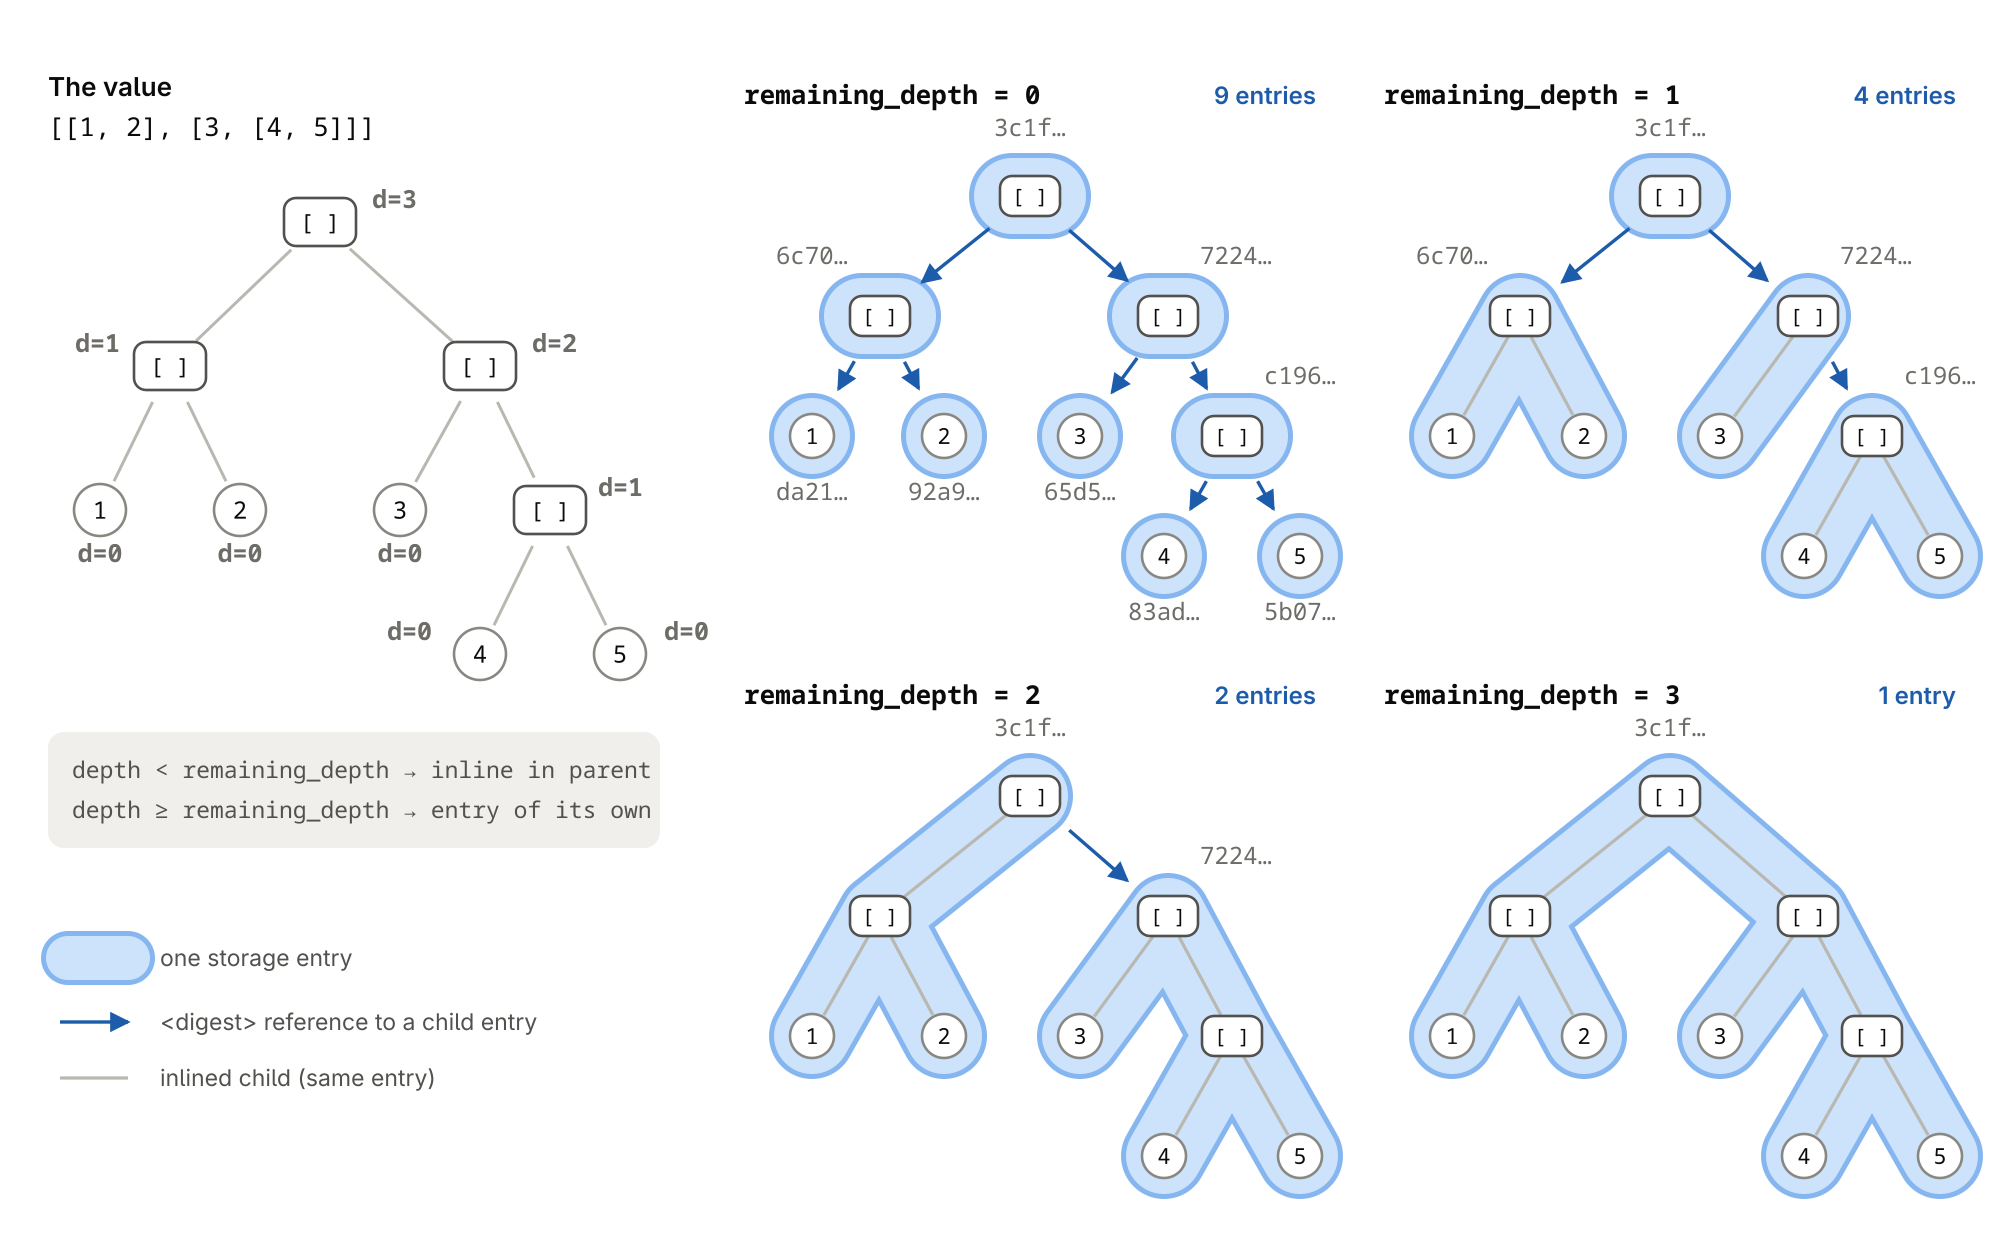

The entry counts of the four panels, reproduced:

In [5]:
value = [[1, 2], [3, [4, 5]]]

for depth in range(4):
    values = ValueMemory({}, remaining_depth=depth)
    values.save(value)
    n = len(values.storage)
    print(f"remaining_depth={depth}: {n} {'entry' if n == 1 else 'entries'}")

remaining_depth=0: 9 entries
remaining_depth=1: 4 entries
remaining_depth=2: 2 entries
remaining_depth=3: 1 entry


The default layout (`remaining_depth = 1`) in detail — compare with the second panel of the figure:

In [6]:
values = ValueMemory({}, remaining_depth=1)
root = values.save(value)
dump(values)

6c70…  [1, 2]
c196…  [4, 5]
7224…  DigestedIterable(items=[3, 'c196…'])
3c1f…  DigestedIterable(items=['6c70…', '7224…'])


`child_digests()` exposes the reference edges (the blue arrows in the figure) without mending:

In [7]:
{values.shrink(k) + "\u2026" for k in values.child_digests(root)}

{'6c70…', '7224…'}

Because entries are content-addressed, a value's digest does not depend on how it was split: saving under any `remaining_depth` yields the same root key. That is why one set of digest labels serves all four panels of the figure.

In [8]:
{ValueMemory({}, remaining_depth=d).save(value) for d in range(4)}

{'3c1fbc86054b4e7a2f94f97e6ca92e48286226a9e0f0f1e3a6b6a43af7e64cf8'}

## Special cases

Three kinds of value break the regular depth pattern:

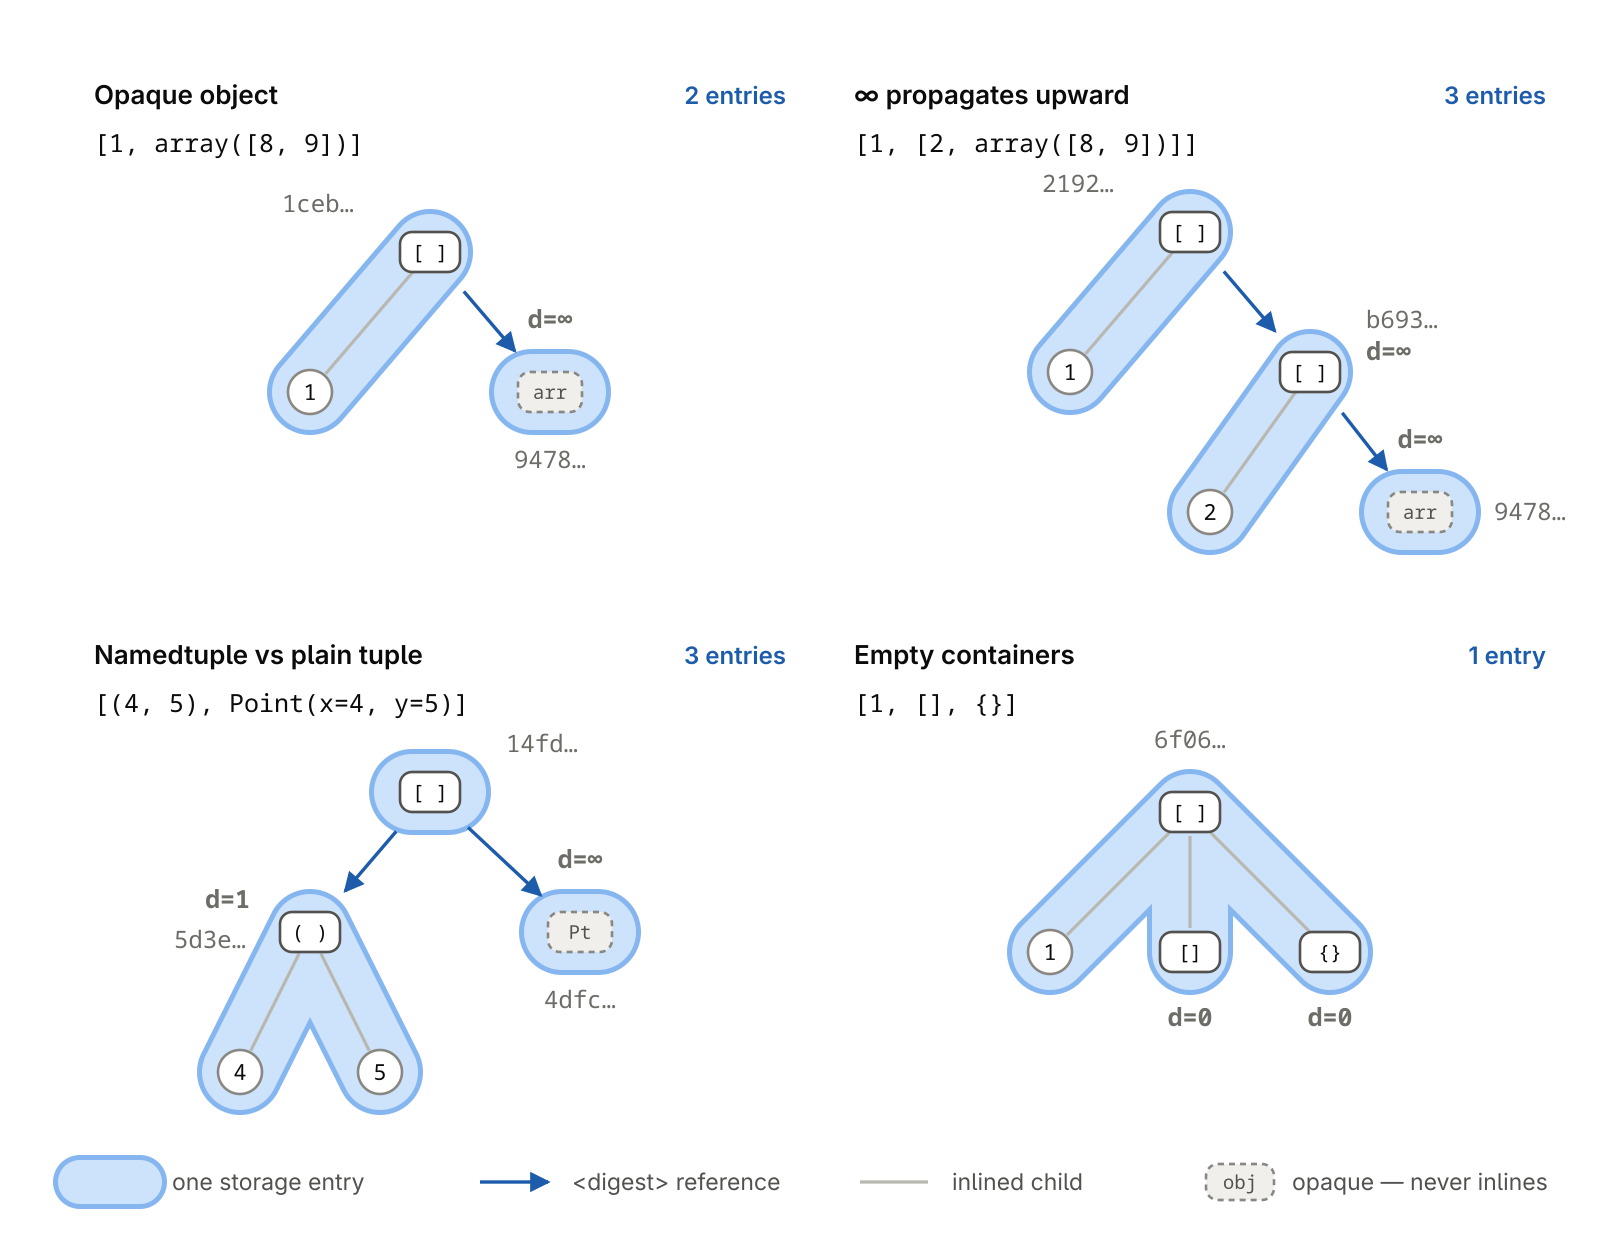

### Opaque objects

Only `list`, `tuple`, `dict`, dataclasses, and attrs classes are destructured. Everything else — numpy arrays, sets, arbitrary objects — is *opaque*: depth ∞, always an entry of its own, at every `remaining_depth`:

In [9]:
import numpy as np

values = ValueMemory({})
values.save([1, np.array([8, 9])])
dump(values)

9478…  array([8, 9])
1ceb…  DigestedIterable(items=[1, '9478…'])


Even a huge `remaining_depth` cannot inline it:

In [10]:
values = ValueMemory({}, remaining_depth=99)
values.save([1, np.array([8, 9])])
len(values.storage)

2

### ∞ propagates upward

A container holding an opaque value has depth `1 + max(child depths) = ∞` as well, so it also splits at every setting:

In [11]:
values = ValueMemory({})
values.save([1, [2, np.array([8, 9])]])
dump(values)

9478…  array([8, 9])
b693…  DigestedIterable(items=[2, '9478…'])
2192…  DigestedIterable(items=[1, 'b693…'])


### Namedtuples vs plain tuples

A plain tuple destructures normally. A namedtuple is deliberately kept opaque: its constructor does not accept a single iterable the way `tuple` does, so fleche refuses to take it apart:

In [12]:
from collections import namedtuple

Point = namedtuple("Point", ["x", "y"])

values = ValueMemory({})
values.save([(4, 5), Point(4, 5)])
dump(values)

5d3e…  (4, 5)
4dfc…  Point(x=4, y=5)
14fd…  DigestedIterable(items=['5d3e…', '4dfc…'])


### Empty containers

`[]`, `()`, and `{}` count as scalars (depth 0) — there is nothing to split, so they inline with their parent like any other leaf:

In [13]:
values = ValueMemory({})
values.save([1, [], {}])
dump(values)

6f06…  [1, [], {}]


## Where to go from here

- Set `values.remaining_depth` in your `fleche.toml` cache section to tune the trade-off: lower values mean more, smaller entries and more sharing between saves; higher values mean fewer, larger entries.
- `register_destructurer()` (re-exported from `fleche.storage`) teaches the storage to split additional container types.